## Tensors

What is a tensor?

A vector is 1-D tensor, a matrix is a 2-D tensor, an array with three indices is a 3-D tensor (RGB Colored images for example). The fundamental data structure for neural networks are tensors and PyTorch is built around them.

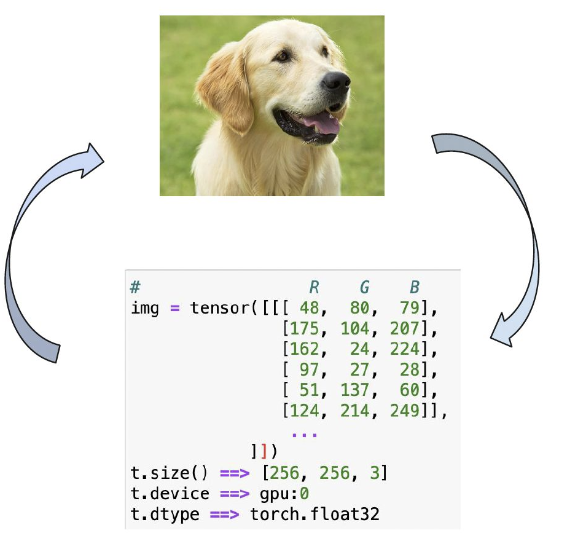

In [1]:
import torch 
import numpy as np


## Initializing a Tensor


You can initialise a tensor multiple ways. You can initialize directly from input data, a numpy array, or from another tensor.

In [2]:
my_data_1 = [[1,2], [3,4]] 
my_tensor_1 = torch.tensor(my_data_1)
my_tensor_1

tensor([[1, 2],
        [3, 4]])

In [3]:
my_array_1 = np.array(my_data_1)
my_array_1

array([[1, 2],
       [3, 4]])

In [4]:
my_tensor_1 = torch.from_numpy(my_array_1)
my_tensor_1

tensor([[1, 2],
        [3, 4]])

If you initialize from another tensor, the new tensor retains the properties (shape, datatype) of the argument/input tensor, unless specified otherwise.

In [5]:
my_ones_tensor = torch.ones_like(my_tensor_1)
my_ones_tensor

tensor([[1, 1],
        [1, 1]])

In [6]:
# we are overriding the datatype of the original tensor
my_rand_tensor = torch.rand_like(my_tensor_1, dtype=torch.float) 
my_rand_tensor

tensor([[0.1305, 0.0455],
        [0.1467, 0.2365]])

## Attributes of a Tensor

Tensor attributes describe their **shape, datatype, and device** on which they are stored.

In [7]:
my_tensor = torch.rand(3,4)

print(f'Original Tensor: {my_tensor}')
print(f'Shape: {my_tensor.shape}')
print(f'Datatype: {my_tensor.dtype}')
print(f'Tensor storage device: {my_tensor.device}')

Original Tensor: tensor([[0.1228, 0.1638, 0.1366, 0.8986],
        [0.7536, 0.3706, 0.2607, 0.3256],
        [0.5577, 0.3706, 0.9722, 0.3140]])
Shape: torch.Size([3, 4])
Datatype: torch.float32
Tensor storage device: cpu


By default, tensors are created on the CPU. We need to explicitly move them to the GPU using the .to method

In [8]:
if torch.cuda.is_available():
    my_tensor = my_tensor.to('cuda')

In [9]:
my_tensor.device

device(type='cpu')

Cuda is not available on my local machine

## Operations on Tensors

#### Indexing and slicing

In [10]:
my_tensor = torch.ones(4,4)
my_tensor[:,1] = 0
print('Full tensor: ', my_tensor)
print('First row: ', my_tensor[0])
print('First column: ', my_tensor[:,0])
print('Last column: ', my_tensor[:,-1])


Full tensor:  tensor([[1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.]])
First row:  tensor([1., 0., 1., 1.])
First column:  tensor([1., 1., 1., 1.])
Last column:  tensor([1., 1., 1., 1.])


#### Arithhmetic Operations

In [11]:
# Matrix multiplication between two tensors
y1 = my_tensor @ my_tensor.T
print(y1)

y2 = my_tensor.matmul(my_tensor.T)
print(y2)

tensor([[3., 3., 3., 3.],
        [3., 3., 3., 3.],
        [3., 3., 3., 3.],
        [3., 3., 3., 3.]])
tensor([[3., 3., 3., 3.],
        [3., 3., 3., 3.],
        [3., 3., 3., 3.],
        [3., 3., 3., 3.]])


In [12]:
# Element-wise product
z1 = my_tensor * my_tensor
print(z1)

z2 = my_tensor.mul(my_tensor)
print(z2)

tensor([[1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.]])
tensor([[1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.]])


In [13]:
# Element-wise addition
x1 = my_tensor.add(my_tensor)
print(x1)

tensor([[2., 0., 2., 2.],
        [2., 0., 2., 2.],
        [2., 0., 2., 2.],
        [2., 0., 2., 2.]])


## Exercise for the practicioner

#### 1. Create a random tensor with shape (7,7)


In [14]:
my_tensor = torch.rand(7,7)
my_tensor.shape

torch.Size([7, 7])

In [15]:
my_tensor

tensor([[0.4592, 0.0964, 0.3995, 0.8962, 0.6152, 0.4152, 0.9228],
        [0.1907, 0.7598, 0.3120, 0.3873, 0.8273, 0.4471, 0.3380],
        [0.8881, 0.2316, 0.9342, 0.9821, 0.2372, 0.1984, 0.9386],
        [0.4253, 0.5999, 0.5436, 0.9885, 0.6036, 0.1068, 0.0740],
        [0.9525, 0.2311, 0.9049, 0.4776, 0.3045, 0.0840, 0.7949],
        [0.8104, 0.4462, 0.1797, 0.8705, 0.3058, 0.3072, 0.3832],
        [0.1160, 0.3933, 0.2345, 0.4475, 0.5628, 0.0249, 0.3619]])

#### 2. Perform a matrix multiplication on the tensor you created with another random tensor with shape (1,7).


In [16]:
my_tensor_2 = torch.rand(1,7)
my_tensor_3 = my_tensor.matmul(my_tensor_2.T)

In [17]:
my_tensor_2

tensor([[0.8217, 0.8978, 0.3406, 0.6649, 0.3764, 0.6382, 0.3691]])

In [18]:
my_tensor_3

tensor([[2.0330],
        [1.9242],
        [2.4712],
        [2.0532],
        [2.0776],
        [2.1591],
        [1.1872]])

#### 3. Set the random seed to 0 and do step 1 & 2 again.

The output should be:
```
(tensor([[1.8542],
         [1.9611],
         [2.2884],
         [3.0481],
         [1.7067],
         [2.5290],
         [1.7989]]), torch.Size([7, 1]))
```

In [19]:
torch.manual_seed(0)
my_tensor = torch.rand(7,7)
my_tensor_2 = torch.rand(1,7)
my_tensor_3 = my_tensor.matmul(my_tensor_2.T)
my_tensor_3

tensor([[1.8542],
        [1.9611],
        [2.2884],
        [3.0481],
        [1.7067],
        [2.5290],
        [1.7989]])

#### 4. Speaking of random seeds, we saw how to set it with torch.manual_seed() but is there a GPU equivalent? (hint: you'll need to look into the documentation for torch.cuda for this one)


In [20]:
torch.cuda.manual_seed_all(0)

#### 5. Create two random tensors of shape (2, 3) and send them both to the GPU (you'll need access to a GPU for this). Set torch.manual_seed(1234) when creating the tensors (this doesn't have to be the GPU random seed).

In [21]:
torch.manual_seed(1234)
torch.cuda.manual_seed_all(1234)
my_tensor_1 = torch.rand(2,3)
my_tensor_2 = torch.rand(2,3)

if torch.cuda.is_available():
    my_tensor_1 = my_tensor_1.to('cuda')
    my_tensor_2 = my_tensor_2.to('cuda')

 #### 6. Perform a matrix multiplication on the tensors you created in step 5 (again, you may have to adjust the shapes of one of the tensors).

In [22]:
my_tensor_3 = my_tensor_1 @ my_tensor_2.T
my_tensor_3

tensor([[0.3647, 0.4709],
        [0.5184, 0.5617]])

#### 7. Find the maximum and minimum values of the output of step 6.

In [23]:
my_max = my_tensor_3.max()
print('Max Tensor: ', my_max)
my_min = my_tensor_3.min()
print('Min Tensor: ', my_min)

Max Tensor:  tensor(0.5617)
Min Tensor:  tensor(0.3647)


#### 8. Find the maximum and minimum index values of the output of step 6.

In [24]:
my_max_idx = my_tensor_3.argmax()
print('Max Tensor Index: ', my_max_idx)

my_min_idx = my_tensor_3.argmin()
print('Max Tensor Index: ', my_min_idx)

Max Tensor Index:  tensor(3)
Max Tensor Index:  tensor(0)


#### 9. Make a random tensor with shape (1, 1, 1, 10) and then create a new tensor with all the 1 dimensions removed to be left with a tensor of shape (10). Set the seed to 7 when you create it and print out the first tensor and it's shape as well as the second tensor and it's shape.

In [25]:
torch.manual_seed(7)
my_tensor_1 = torch.rand(1,1,1,10)
print('Original tensor shape: ', my_tensor_1.shape)
my_tensor_squeezed = my_tensor_1.squeeze()
print('Squeezed tensor shape: ', my_tensor_squeezed.shape)

Original tensor shape:  torch.Size([1, 1, 1, 10])
Squeezed tensor shape:  torch.Size([10])


## Datasets & DataLoaders

The Dataset and DataLoader classes encapsulate the process of pulling your data from storage and exposing it to your training loop in batches.

The Dataset is responsible for accessing and processing single instances of data.

The DataLoader pulls instances of data from the Dataset (either automatically or with a sampler that you
define), collects them in batches, and returns them for consumption by your training loop. The DataLoader
works with all kinds of datasets, regardless of the type of data they contain

In [68]:
import os
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
import matplotlib.pyplot as plt
import requests
from zipfile import ZipFile
from io import BytesIO
import numpy as np


### Downloading a dataset (using GET requests)

In [28]:
# Use a relative path (./) instead of root (/)
local_zip_path = './tiny-imagenet-200.zip'
extract_path = './data' 

if not os.path.exists(extract_path):
    response = requests.get('http://cs231n.stanford.edu/tiny-imagenet-200.zip')
    if response.status_code == 200:
        print('Downloading and extracting dataset...')
        with ZipFile(BytesIO(response.content)) as zip_file:
            zip_file.extractall(extract_path)
        print('Done!')
else:
    print('Dataset already exists locally.')

Done!


### Defining Transformations

In PyTorch, raw images are just arrays of pixels. To feed them into a Neural Network, we need to transform them into **Tensors** and **Normalize** the values.

Tiny ImageNet images are $64 x 64$ pixels. We usually use the standard ImageNet normalization constants because most pre-trained models expect them.


In [79]:
transform = transforms.Compose([
    transforms.Resize((256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                         std=[0.229, 0.224, 0.225])
])

We can't use the exact same transformations all three datasets. While some steps like resizing and normalizing are mandatory for all, you usually want to add **Data Augmentation** to your training set while keeping your validation and test sets 'clean'.

#### 1. Training vs. Validation/Test Logic

Think of it this way:

 - Training Set: You want to make the "gym" as hard as possible. You flip the images, rotate them, and change the lighting so the model learns to recognize a cat regardless of its orientation.

 - Validation/Test Set: You want to see how the model performs on real-world, "natural" images. If you randomly crop or flip your test images, you are essentially testing the model on "fake" data, which makes your accuracy metrics less reliable.

In [80]:
train_transform = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(p=0.25),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                         std=[0.229, 0.224, 0.225])
])

In [81]:
test_transform = transform # the standard version where we just resize, make tensor, and normalize

### Loading with ImageFolder

ImageFolder is a 'smart' loader. It looks at a directory, treats each subdirectory as a class name (label), and assigns an integer to it automatically.

**Note for ImageNet**: The test folder in this specific dataset doesn't have subdirectories (it's unlabelled data for competition). Most labs use a validation folder for testing during the project. 

In [82]:
dataset_train = ImageFolder(root='./data/tiny-imagenet-200/train', transform=train_transform)
loader_train = DataLoader(dataset_train, batch_size=64, shuffle=True)

In [83]:
print(f"Successfully loaded {len(dataset_train)} training images.")
print(f"Found {len(dataset_train.classes)} classes.")

Successfully loaded 100000 training images.
Found 200 classes.


#### Why do we need the DataLoader?

While the Dataset object is like a library (it knows where the books are), the DataLoader is like a librarian who fetches a specific number of books (**batch size**), and shuffles them so you don't learn in a fixed order.

In [84]:
import io
import pandas as pd

val_dir = './data/tiny-imagenet-200/val'
annotations_file = os.path.join(val_dir, 'val_annotations.txt')

# Read the annotations (TSV format)
# Format: [file_name, class_id, x, y, h, w]
val_data = pd.read_csv(annotations_file, sep='\t', header=None, 
                       names=['File', 'Class', 'X', 'Y', 'H', 'W'])

# Create subdirectories for each class inside val/images
for _, row in val_data.iterrows():
    file_name = row['File']
    class_id = row['Class']
    
    # Create the class directory if it doesn't exist
    target_dir = os.path.join(val_dir, 'images', class_id)
    if not os.path.exists(target_dir):
        os.makedirs(target_dir)
    
    # Move the file from val/images/ to val/images/class_id/
    src_path = os.path.join(val_dir, 'images', file_name)
    dst_path = os.path.join(target_dir, file_name)
    
    if os.path.exists(src_path):
        os.rename(src_path, dst_path)

print("Validation folder reorganized!")

Validation folder reorganized!


In [85]:
dataset_val = ImageFolder(root='./data/tiny-imagenet-200/val/images', transform=test_transform)
loader_val = DataLoader(dataset_val, batch_size=64, shuffle=True)

In [86]:
# Crucial Check: Ensure the mapping is the same
assert dataset_train.class_to_idx == dataset_val.class_to_idx
print(f"Ready to train on {len(dataset_train.classes)} classes!")

Ready to train on 200 classes!


In [87]:
print(f"Successfully loaded {len(dataset_val)} validation images.")
print(f"Found {len(dataset_val.classes)} classes.")

Successfully loaded 10000 validation images.
Found 200 classes.


In [88]:
dataset_test = ImageFolder(root='./data/tiny-imagenet-200/test', transform=test_transform)
loader_test = DataLoader(dataset_test, batch_size=64, shuffle=True)

In [89]:
print(f"Successfully loaded {len(dataset_test)} test images.")

Successfully loaded 10000 test images.


In [ ]:
# Function to denormalize image for visualization
def denormalize(image):
    image = image.to('cpu').numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    image = image * std + mean
    image = np.clip(image, 0, 1)
    return image

Our final task is to visualize one example for class for 10 of the dataset's classes.

To make this work, we have to bridge the gap between how **PyTorch** sees an image (a normalized, mathematical Tensor) and how **Matplotlib** sees an image (a grid of pixels).

First of all, the **loader_train** doesn't give you one image at a time; it gives you a **batch**.
- Inside the for loop, we'll need a second loop to iterate through the current batch
- Then, we must check if the label is already in sampled classes before proceeding.

Now inside the loop, if you try to plot the inputs directly in matplotlib, they will look like colorful static or dark blobs. This is because:
1. **Normalization**: We subtracted the mean and divided by the std. We must 'un-normalize'.
2. **Dimension Order**: PyTorch uses **CHW** (Channels, Height, Width), but Matplotlib expects **HWC**. We'll need to permute the tensor.

Also, since we defined axes as a $2 x 5$ grid, axes is a 2-D array. We can use flatten() to get a single 1-D index. This makes it easier to plot images 0 through 9 without worrying about row/column math.



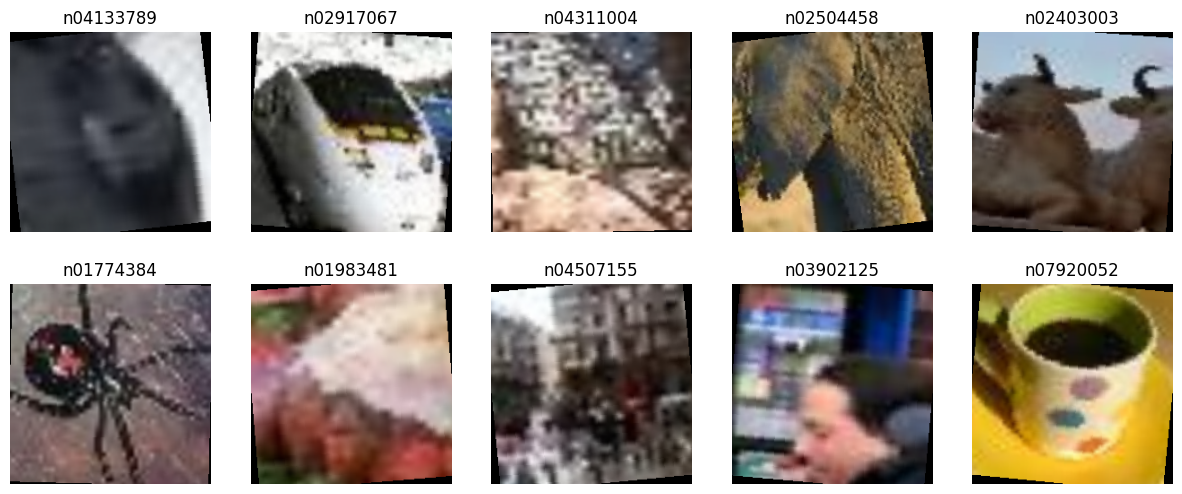

In [105]:
# Visualize one example for each class for 10 classes
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
classes_sampled = []
found_classes = 0

for i, (inputs, classes) in enumerate(loader_train):
    for img, label in zip(inputs, classes):
        label_idx = label.item()
        if not (label in classes_sampled):
            ax = axes.flatten()[found_classes]
            img = denormalize(img)

            ax.imshow(img)
            ax.set_title(dataset_train.classes[label_idx])
            ax.axis('off') # Optional: hides the X/Y pixel coordinates

            classes_sampled.append(label)
            found_classes += 1
        if found_classes == 10:
            break
    if found_classes == 10:
        break   
ax.set_title(dataset_train.classes[label])
plt.show()